## Desafio 4 — Estimação de Pose com YOLO

Estimação de pose detecta keypoints do corpo humano — articulações como ombro, cotovelo, joelho — em vez de só um bounding box. Útil em análises esportivas e sistemas de reabilitação.

O modelo `yolo11n-pose.pt` é a versão nano, bem leve. Para imagens estáticas funciona bem; em vídeo mais exigente valeria considerar um modelo maior.

### Instalação e Importação da Biblioteca

In [1]:
!pip install ultralytics matplotlib torch

In [2]:
import ultralytics
import matplotlib.pyplot as plt
import torch

### Processar Dados

In [3]:
# Baixa o modelo de pose da YOLO.
model = ultralytics.YOLO("yolo11n-pose.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Processa a imagem.
# TODO testar outras imagens.
results = model("desafio_4.jpeg")  # predict on an image


image 1/1 /Users/larry/Documents/Dev/Residencia/Jupyter Notebooks/DesafiosExtras/Desafio4/desafio_4.jpeg: 288x640 5 persons, 50.2ms
Speed: 6.1ms preprocess, 50.2ms inference, 8.9ms postprocess per image at shape (1, 3, 288, 640)


### Visualizar Resultados

O `results[0].plot()` retorna um array BGR com os keypoints e conexões desenhados. Precisei converter para RGB antes de mostrar com matplotlib — o esqueleto ficou com as cores certas só depois disso.

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: ultralytics.engine.results.Keypoints object
masks: None
names: {0: 'person'}
obb: None
orig_img: array([[[119, 140, 131],
        [118, 139, 130],
        [120, 139, 130],
        ...,
        [183, 220, 204],
        [194, 228, 211],
        [223, 246, 231]],

       [[120, 139, 130],
        [118, 137, 128],
        [118, 137, 128],
        ...,
        [200, 233, 219],
        [190, 226, 210],
        [199, 228, 212]],

       [[118, 137, 128],
        [117, 136, 127],
        [117, 136, 127],
        ...,
        [219, 247, 241],
        [204, 236, 225],
        [201, 227, 213]],

       ...,

       [[113, 134, 165],
        [113, 134, 162],
        [ 98, 115, 141],
        ...,
        [128, 121,  58],
        [128, 124,  59],
        [118, 115,  47]],

       [[107, 128, 159],
        [102, 123, 151],
        [ 98, 115, 141],
        ...,
        [116, 107,  44],

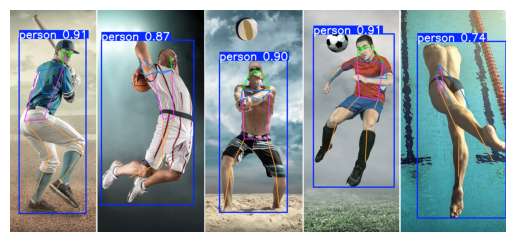

In [4]:
from PIL import Image
import cv2

print(results[0])

# Gera visualização do resultado
im_array = results[0].plot()
rgb_img = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)

# Visualize a imagem rgb_img
plt.imshow(rgb_img)
plt.axis("off")
plt.show()

### Referência

- https://docs.ultralytics.com/tasks/pose